## Desafío: Optimización de Logística Urbana en Buenos Aires

### Consigna

Sos el analista principal de datos en una app de envíos rápidos que opera en la Ciudad Autónoma de Buenos Aires (CABA) y sus alrededores. El equipo directivo te pide un informe integral para entender por qué bajó el rendimiento en la Zona Sur, visualizar la cobertura espacial de los repartos sobre el mapa porteño y descubrir estadísticamente qué factores impactan más en las demoras y en la satisfacción de los clientes.

Tenés a disposición un dataset con 1500 registros de entregas recientes (medidas rigurosamente en **kilómetros**). Deberás aplicar técnicas de storytelling visual, análisis geoespacial y estadística para presentar tus hallazgos.

### Tareas a realizar

1. **Storytelling (Reporte Estático):** Armar un gráfico de barras narrativo que explique la caída del volumen de entregas en la Zona Sur durante el último
mes debido a un corte prolongado en el Puente Pueyrredón, dejando el mensaje clave anotado directamente en el gráfico.
2. **Storytelling (Dashboard Interactivo):** Crear un gráfico de líneas interactivo con un menú desplegable (dropdown) que permita al gerente de operaciones revisar el tiempo promedio de entrega mes a mes, filtrando por zona de Buenos Aires (Norte, Sur, Caballito/Centro, etc.).
3. **Análisis Espacial (Mapa GIS):** Generar un mapa interactivo de burbujas centrado en CABA. El tamaño de la burbuja debe representar el costo del envío (ARS) y el color debe indicar el nivel de satisfacción del cliente (1 a 5).
4. **Análisis Estadístico (Univariado):** Analizar la distribución de la **distancia de los trayectos en kilómetros** calculando la media y el desvío estándar, y visualizarlo mediante un histograma con la media y mediana marcadas.
5. **Análisis Estadístico (Bivariado y Multivariado):** Evaluar la correlación entre la distancia (km), el tiempo de entrega (min), el costo (ARS) y la satisfacción del cliente usando un mapa de calor (heatmap).

In [51]:
DATASET_URL :str = "https://gist.githubusercontent.com/Andru-1987/e59deadf655c23c980dc9fb4abfe4411/raw/f336d2cc0c6fdd495b5690aa739cd30f2060c7b4/logistica_caba.csv"

In [52]:
# Declaracion de Dependecias
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [53]:
df = pd.read_csv( DATASET_URL , encoding='utf8')

In [54]:
df["satisfaccion_cliente"] = df.satisfaccion_cliente.astype('category')
df['costo_envio_ars'] = df['costo_envio_ars'].astype(np.float32)
df['tiempo_entrega_min'] = pd.to_numeric(df['tiempo_entrega_min'], downcast='float')

In [55]:
month_mapper = {
    "Ene": "Jan",
    "Feb": "Feb",
    "Mar": "Mar",
    "Abr": "Apr",
    "May": "May",
    "Jun": "Jun",
    "Jul": "Jul",
    "Ago": "Aug",
    "Sep": "Sep",
    "Oct": "Oct",
    "Nov": "Nov",
    "Dic": "Dec",
}

df["mes"] = df["mes"].map(month_mapper)

In [56]:
df.satisfaccion_cliente.value_counts()

,count
satisfaccion_cliente,
5,848
4,600
3,51
2,1


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   id_pedido             1500 non-null   object  
 1   mes                   1500 non-null   object  
 2   zona                  1500 non-null   object  
 3   latitud               1500 non-null   float64 
 4   longitud              1500 non-null   float64 
 5   distancia_km          1500 non-null   float64 
 6   tiempo_entrega_min    1500 non-null   float32 
 7   costo_envio_ars       1500 non-null   float32 
 8   satisfaccion_cliente  1500 non-null   category
dtypes: category(1), float32(2), float64(3), object(3)
memory usage: 83.8+ KB


In [58]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitud,1500.0,-34.590350,0.033958,-34.649929,-34.617910,-34.591416,-34.561611,-34.530152
longitud,1500.0,-58.437562,0.051287,-58.529577,-58.481074,-58.434811,-58.392752,-58.350021
distancia_km,1500.0,4.773187,4.447679,0.800000,1.397500,3.260000,6.470000,22.000000
tiempo_entrega_min,1500.0,36.721401,16.431461,10.000000,24.075000,35.549999,45.500000,100.900002
costo_envio_ars,1500.0,7032.069824,4240.022461,3000.000000,3824.000000,5646.500000,8693.000000,24207.000000


In [59]:
df.describe(include=['object','category']).T

,count,unique,top,freq
id_pedido,1500,1500,BUE-1500,1
mes,1500,6,Feb,265
zona,1500,4,Centro (Microcentro),559
satisfaccion_cliente,1500,4,5,848


In [60]:
df.sample(10)

,id_pedido,mes,zona,latitud,longitud,distancia_km,tiempo_entrega_min,costo_envio_ars,satisfaccion_cliente
546,BUE-0547,May,Norte (Belgrano/Nuñez),-34.553134,-58.394286,9.04,42.700001,10966.0,5
1293,BUE-1294,Jan,Norte (Belgrano/Nuñez),-34.580103,-58.513230,0.80,15.700000,3033.0,5
86,BUE-0087,Jan,Oeste (Flores/Liniers),-34.581064,-58.458931,0.80,16.000000,3560.0,5
1393,BUE-1394,Jan,Sur (Barracas/Avellaneda),-34.640644,-58.432727,1.03,36.000000,3450.0,4
1459,BUE-1460,Feb,Norte (Belgrano/Nuñez),-34.578762,-58.354436,0.80,11.700000,3856.0,5
175,BUE-0176,Mar,Norte (Belgrano/Nuñez),-34.565929,-58.486027,0.80,14.800000,3513.0,5
201,BUE-0202,May,Centro (Microcentro),-34.586909,-58.524386,6.39,52.200001,8250.0,4
1268,BUE-1269,Mar,Centro (Microcentro),-34.597383,-58.524645,0.80,33.200001,3853.0,4
1212,BUE-1213,May,Oeste (Flores/Liniers),-34.604775,-58.376108,0.80,19.100000,3224.0,5
1302,BUE-1303,Apr,Centro (Microcentro),-34.560594,-58.363631,1.31,34.500000,4249.0,4


In [61]:
df.mes.value_counts()

,count
mes,
Feb,265
Jan,257
Mar,256
Jun,251
May,241
Apr,230


In [67]:
df['mes'] = pd.to_datetime(df.mes , format='%b')

last_month = df['mes'].max()


In [ ]:
# 1 Challenge
df_entregas = df.copy()
df_volumen  =  df_entregas.groupby(["zona","mes"]).size().reset_index(name="entregas")
df_volumen  = df_volumen.sort_values("entregas", ascending=False)
df_volumen_last_month  = df_volumen[df_volumen.mes == last_month]
df_volumen_last_month

,zona,mes,entregas
5,Centro (Microcentro),1900-06-01,83
17,Oeste (Flores/Liniers),1900-06-01,64
11,Norte (Belgrano/Nuñez),1900-06-01,58
23,Sur (Barracas/Avellaneda),1900-06-01,46


In [78]:
import re

has_match = bool(re.search(r"\d+", "Order number: 12345"))
colors = [  '#c0392b' if  bool(re.search('Sur', zone)) else '#bdc3c7' for zone  in df_volumen_last_month.zona ]

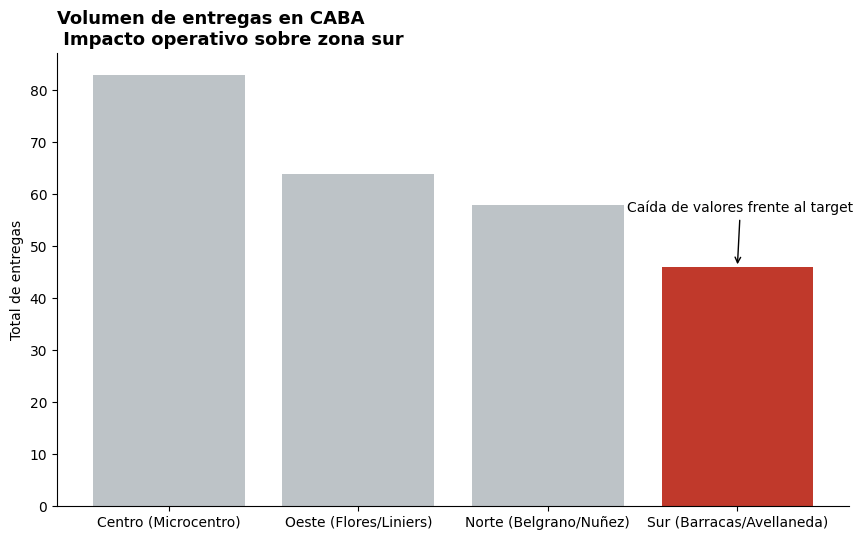

In [100]:

fig,ax =  plt.subplots(figsize=(9,5.5))

ax.bar(df_volumen_last_month.zona, df_volumen_last_month.entregas, color = colors)
ax.set_title("Volumen de entregas en CABA\n Impacto operativo sobre zona sur", fontsize=13, fontweight = 'bold', loc="left")

ax.set_ylabel("Total de entregas")

ax.spines[["top","right"]].set_visible(False)

sur = df_volumen_last_month.loc[
    df_volumen_last_month["zona"] == "Sur (Barracas/Avellaneda)"
].iloc[0]

ax.annotate(
    "Caída de valores frente al target",
    xy=("Sur (Barracas/Avellaneda)", sur["entregas"]),
    xytext=(0.72, 0.65),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()


In [ ]:
## 2
df_metricas = df.copy()

In [113]:
df_mensual = df_metricas.groupby(["mes","zona"])["tiempo_entrega_min"].mean().reset_index()
meses = (
    pd.to_datetime(df_metricas["mes"])
    .dt.strftime("%B")
    .unique()
    .tolist()
)

zonas = df_metricas.zona.unique()

In [114]:
meses

['January', 'February', 'May', 'April', 'March', 'June']

In [120]:
fig = go.Figure()

for i, zona in enumerate(zonas):
    df_filtrado = df_mensual[df_mensual["zona"] == zona]
    fig.add_trace(
        go.Scatter(
            x= meses, y = df_filtrado["tiempo_entrega_min"], mode="lines+markers",
            name=zona, visible=(i==0)
        )
    )
 

botones = []

for i,zona  in enumerate(zonas):
    visible = [False] * len(zonas)
    visible[i] = True
    botones.append(
        dict(
            label = zona, 
            method="update",
            args= [{"visible": visible}, {"title": f"Tiempo de entrega promedio: Zona: {zona}"}]
    ))

fig.update_layout(
    title = f"Tiempo de entrega promedio: Zona: {zonas[0]}",
    updatemenus = [dict(active=0, buttons=botones, x=1.10, y=1, xanchor="left")],
    yaxis_title="Minutos promedio",
    xaxis_title = "Mes",
    template="plotly_white"
)


# fig.write_html("interactivo.html")
fig.show()


In [125]:
# Scatter Map
df_sample = df.copy()

df_muestra = df_sample.sample(350, random_state=42)

fig = px.scatter_map(
    df_muestra,
    lat = "latitud",
    lon = "longitud",
    color = "satisfaccion_cliente",
    size = "costo_envio_ars",
    hover_name = "id_pedido",
    hover_data = {"latitud":False,"longitud":False, "distancia_km": True},
    color_continuous_scale = px.colors.diverging.RdYlBu, size_max=15,
    zoom=11,
    center =  {"lat": -34.6037 , "lon": -58.3816},
    title = "Mapa de entregas",
    map_style = "carto-positron"
)

fig.show()




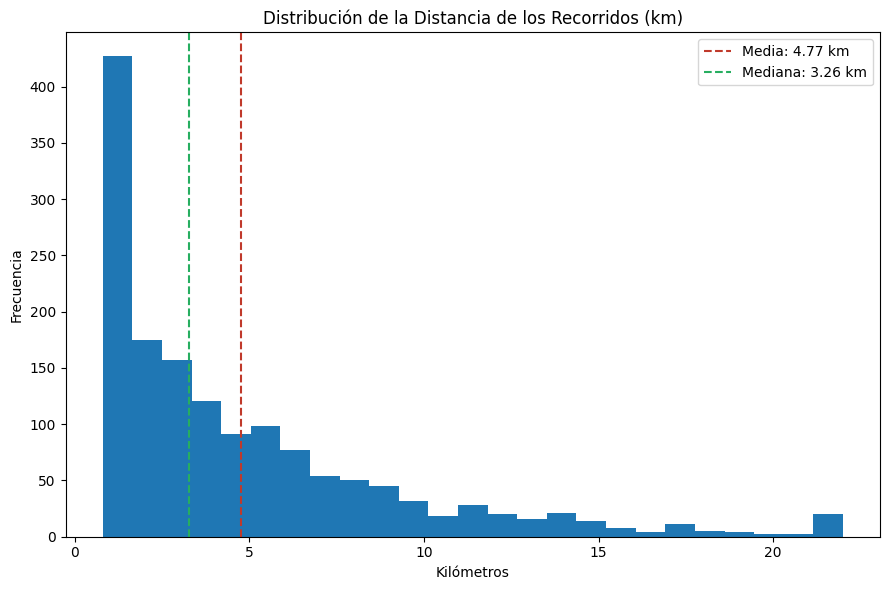

In [130]:
# 4 histograma

df_entrega = df.copy()

media_km =  df_entrega["distancia_km"].mean()
mediana_km =  df_entrega["distancia_km"].median()
desvio_km =  df_entrega["distancia_km"].std(ddof=1)

fig,ax = plt.subplots(figsize=(9,6))

ax.hist(
    df_entrega["distancia_km"], bins=25
)
ax.axvline(media_km, color= "#c0392b", linestyle="--", label = f"Media: {media_km:.2f} km")
ax.axvline(mediana_km, color= "#27ae60", linestyle="--", label = f"Mediana: {mediana_km:.2f} km")


ax.set_title("Distribución de la Distancia de los Recorridos (km)")
ax.set_xlabel("Kilómetros")
ax.set_ylabel("Frecuencia")

ax.legend()
plt.tight_layout()
plt.show()




In [133]:
# heatmap

cols_numericas = ["distancia_km", "tiempo_entrega_min", "costo_envio_ars", "satisfaccion_cliente"]
matriz_corr = df[cols_numericas].corr()

matriz_corr

,distancia_km,tiempo_entrega_min,costo_envio_ars,satisfaccion_cliente
distancia_km,1.000000,0.779824,0.997654,-0.511019
tiempo_entrega_min,0.779824,1.000000,0.777960,-0.640010
costo_envio_ars,0.997654,0.777960,1.000000,-0.509642
satisfaccion_cliente,-0.511019,-0.640010,-0.509642,1.000000


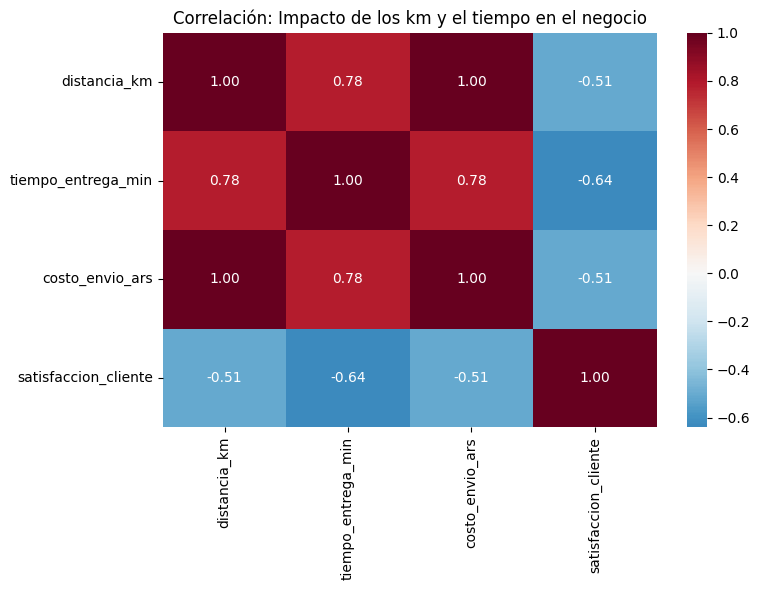

In [134]:

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlación: Impacto de los km y el tiempo en el negocio")
plt.tight_layout()
plt.show()